# Exploratory Chess Analytics

This notebook explores personal chess performance data collected from Chess.com.

Main objectives:
- identify performance patterns
- analyze rating progression
- compare white vs black performance
- evaluate opening effectiveness
- explore behavioral trends

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt, matplotlib.dates as mdates
import seaborn as sns
import sys
from pathlib import Path
import io
import chess.pgn

## Load cleaned dataset

In [2]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
    / f"{USERNAME}_games_clean.csv"
)

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,...,player_result,opponent_result,score,opening,opponent,url,opponent_clean,country_code,iso3,country_name
0,2020-11-10 15:30:24,2020,11,Tuesday,15,white,rapid,600,213,412,...,resigned,win,0.0,Polish Opening,TheMrNoName,https://www.chess.com/game/live/5719328865,themrnoname,US,USA,United States
1,2020-11-10 15:46:19,2020,11,Tuesday,15,black,rapid,600,345,216,...,win,resigned,1.0,Kings Pawn Opening Kings Knight Variation,smackersmashbot,https://www.chess.com/game/live/5719418873,smackersmashbot,PH,PHL,Philippines
2,2020-11-10 16:09:31,2020,11,Tuesday,16,black,rapid,600,256,371,...,checkmated,win,0.0,Kings Pawn Opening Leonardis Variation,amkh98,https://www.chess.com/game/live/5719482469,amkh98,IR,IRN,"Iran, Islamic Republic of"
3,2020-11-10 17:39:54,2020,11,Tuesday,17,white,rapid,600,193,330,...,checkmated,win,0.0,Vienna Game Max Lange Defense,callumfindlay4,https://www.chess.com/game/live/5720005454,callumfindlay4,GB,GBR,United Kingdom
4,2020-11-10 17:51:42,2020,11,Tuesday,17,black,rapid,600,277,291,...,win,resigned,1.0,Caro Kann Defense,callumfindlay4,https://www.chess.com/game/live/5720050101,callumfindlay4,GB,GBR,United Kingdom


## Dataset overview

In [3]:
df.shape

(21007, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21007 entries, 0 to 21006
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             21007 non-null  datetime64[ns]
 1   year             21007 non-null  int64         
 2   month            21007 non-null  int64         
 3   weekday          21007 non-null  object        
 4   hour             21007 non-null  int64         
 5   side             21007 non-null  object        
 6   time_class       21007 non-null  object        
 7   time_control     21007 non-null  object        
 8   player_rating    21007 non-null  int64         
 9   opponent_rating  21007 non-null  int64         
 10  rating_diff      21007 non-null  int64         
 11  result           21007 non-null  object        
 12  player_result    21007 non-null  object        
 13  opponent_result  21007 non-null  object        
 14  score            21007 non-null  float

In [5]:
df.describe(include="all")

,date,year,month,weekday,hour,side,time_class,time_control,player_rating,opponent_rating,...,player_result,opponent_result,score,opening,opponent,url,opponent_clean,country_code,iso3,country_name
count,21007,21007.000000,21007.000000,21007,21007.000000,21007,21007,21007,21007.000000,21007.000000,...,21007,21007,21007.000000,21007,21007,21007,21007,20361,19851,19851
unique,NaN,NaN,NaN,7,NaN,2,4,11,NaN,NaN,...,10,10,NaN,435,20242,21007,20242,223,210,210
top,NaN,NaN,NaN,Monday,NaN,black,blitz,180,NaN,NaN,...,win,win,NaN,Four Knights Game Scotch Variation Accepted,ElettricRunner,https://www.chess.com/game/live/5719328865,elettricrunner,US,USA,United States
freq,NaN,NaN,NaN,3264,NaN,10519,19825,15802,NaN,NaN,...,10182,10157,NaN,1127,33,1,33,3046,3046,3046
mean,2024-06-03 01:08:37.918931712,2023.946875,6.200171,NaN,15.218737,NaN,NaN,NaN,627.966725,628.125577,...,NaN,NaN,0.500595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2020-11-10 15:30:24,2020.000000,1.000000,NaN,0.000000,NaN,NaN,NaN,100.000000,100.000000,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2023-09-06 01:10:40.500000,2023.000000,3.000000,NaN,12.000000,NaN,NaN,NaN,559.000000,563.000000,...,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2024-10-26 22:38:51,2024.000000,6.000000,NaN,16.000000,NaN,NaN,NaN,649.000000,649.000000,...,NaN,NaN,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2025-06-18 13:08:50,2025.000000,9.000000,NaN,20.000000,NaN,NaN,NaN,710.000000,711.000000,...,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2026-05-08 23:49:17,2026.000000,12.000000,NaN,23.000000,NaN,NaN,NaN,1041.000000,1607.000000,...,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Time formats distribution

### Time Class

How the time format is called

In [6]:
df["time_class"].value_counts()

time_class
blitz     19825
rapid       653
bullet      455
daily        74
Name: count, dtype: int64

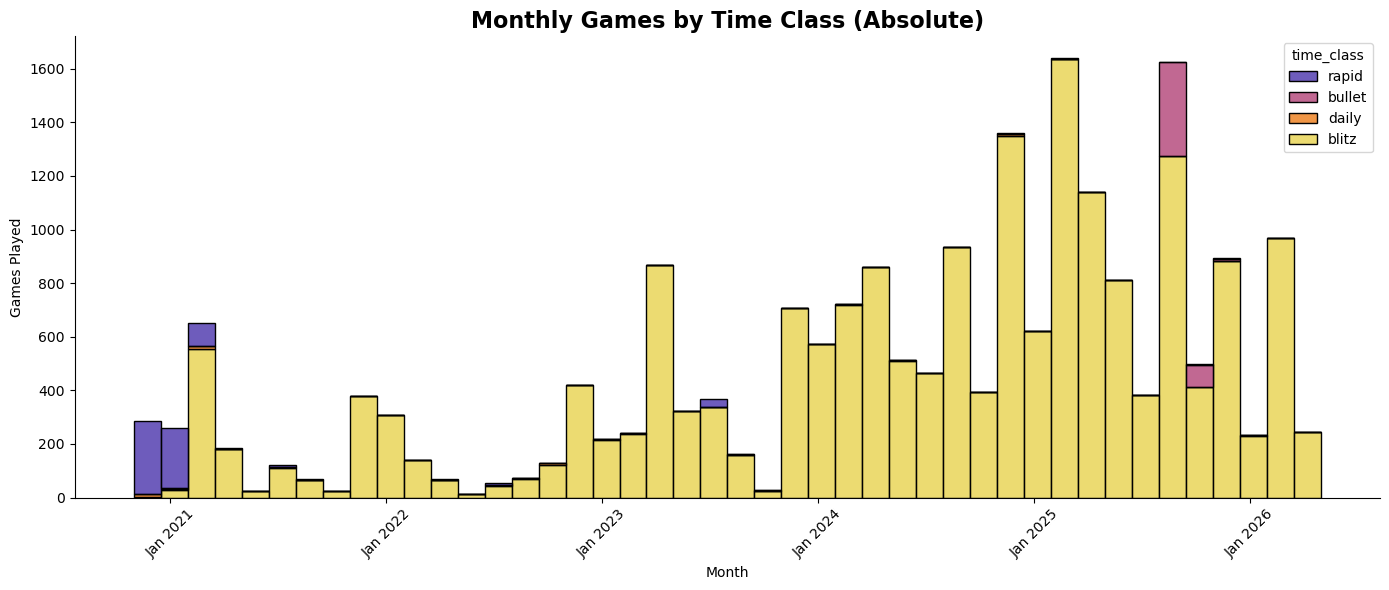

In [7]:

df["month_date"] = pd.to_datetime(df[["year", "month"]].assign(day=1))
monthly = df.groupby(["month_date", "time_class"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 6))

sns.histplot(
    data=df,
    x="month_date",
    hue="time_class",
    multiple="stack",
    palette="CMRmap",
    ax=ax
)

ax.set_title("Monthly Games by Time Class (Absolute)", fontsize=16, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Games Played")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %Y"))
plt.xticks(rotation=45)
sns.despine()
plt.tight_layout()
plt.show()

## Rating progression on short formats

We will take into considerations the shortest time classes: rapid, bullet and blitz (the most popular).

To make the visualisation clearer a median monthly value is chose instead of a daily value; the shade indicates the monthly rage in rating.

In [8]:
rapid = df[
    df["time_class"] == "rapid"
].sort_values("date")
bullet = df[
    df["time_class"] == "bullet"
].sort_values("date")
blitz = df[
    df["time_class"] == "blitz"
].sort_values("date")

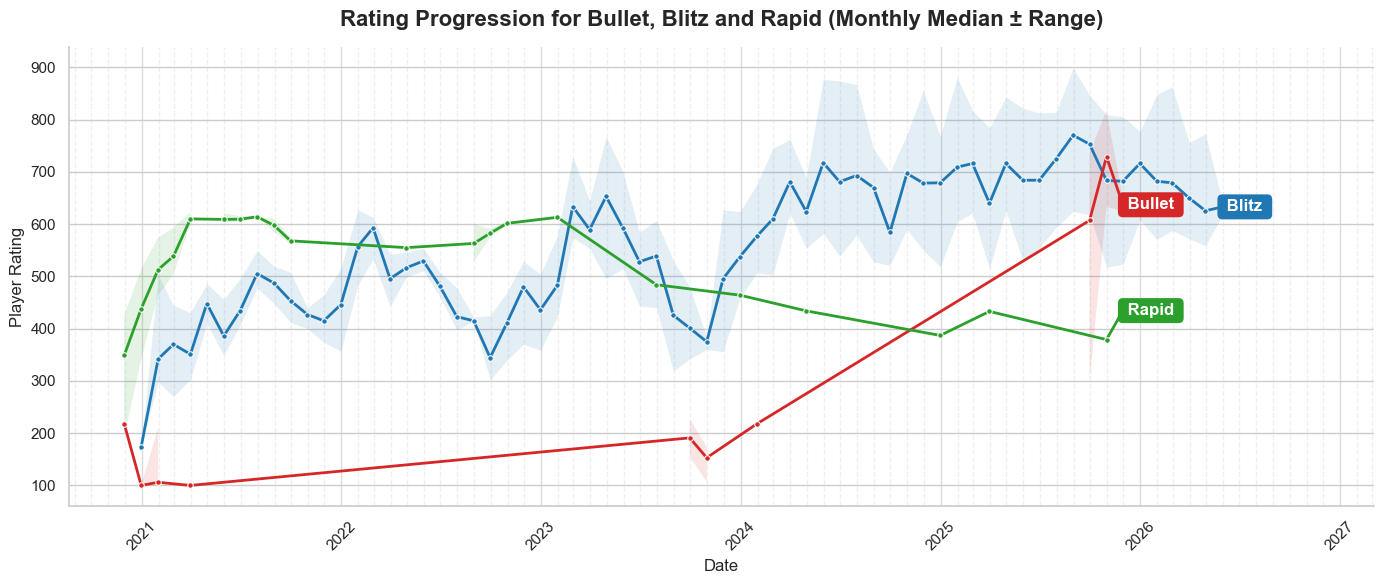

In [9]:
def monthly_stats(df):
    return (
        df.groupby(pd.Grouper(key="date", freq="ME"))["player_rating"]
        .agg(median="median", min="min", max="max")
        .reset_index()
    )

blitz_m  = monthly_stats(blitz)
bullet_m = monthly_stats(bullet)
rapid_m  = monthly_stats(rapid)

# --- PLOT ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 6))

colori = {
    "blitz":  "#1f77b4",
    "bullet": "#d62728",
    "rapid":  "#2ca02c"
}

for df_tc, label in [(blitz_m, "blitz"), (bullet_m, "bullet"), (rapid_m, "rapid")]:
    color = colori[label]

    # Shaded min/max band
    ax.fill_between(
        df_tc["date"],
        df_tc["min"],
        df_tc["max"],
        color=color,
        alpha=0.12,
        linewidth=0
    )

    # Median line
    sns.lineplot(
        data=df_tc,
        x="date",
        y="median",
        color=color,
        linewidth=2,
        marker="o",
        markersize=4,
        ax=ax
    )

# --- DATE CONFIG ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.grid(True, which="minor", axis="x", linestyle="--", alpha=0.3)
ax.grid(True, which="major", axis="x", linestyle="-", alpha=0.7)
plt.xticks(rotation=45)

# --- END LABELS ---
def add_label(df, label_text, color):
    last_date   = df["date"].iloc[-1]
    last_rating = df["median"].iloc[-1]   # 👈 updated to median column
    ax.text(
        last_date, last_rating, f" {label_text} ",
        color="white",
        fontweight="bold",
        va="center",
        bbox=dict(facecolor=color, edgecolor="none", boxstyle="round,pad=0.3")
    )

add_label(blitz_m,  "Blitz",  colori["blitz"])
add_label(bullet_m, "Bullet", colori["bullet"])
add_label(rapid_m,  "Rapid",  colori["rapid"])

# --- LABELS & CLEANUP ---
ax.set_title("Rating Progression for Bullet, Blitz and Rapid (Monthly Median ± Range)", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Player Rating", fontsize=12)
# ax.get_legend().remove()

xmin, xmax = ax.get_xlim()
ax.set_xlim(xmin, xmax + (xmax - xmin) * 0.08)

sns.despine()
plt.tight_layout()
plt.show()

## White vs Black analysis

In [10]:
df.groupby("side")["score"].mean()

side
black    0.477137
white    0.524123
Name: score, dtype: float64

In [11]:
white_black = (
    df.groupby("side")
    .agg({
        "score": "mean",
        "player_rating": "mean"
    })
)

white_black

,score,player_rating
side,,
black,0.477137,627.755015
white,0.524123,628.179062


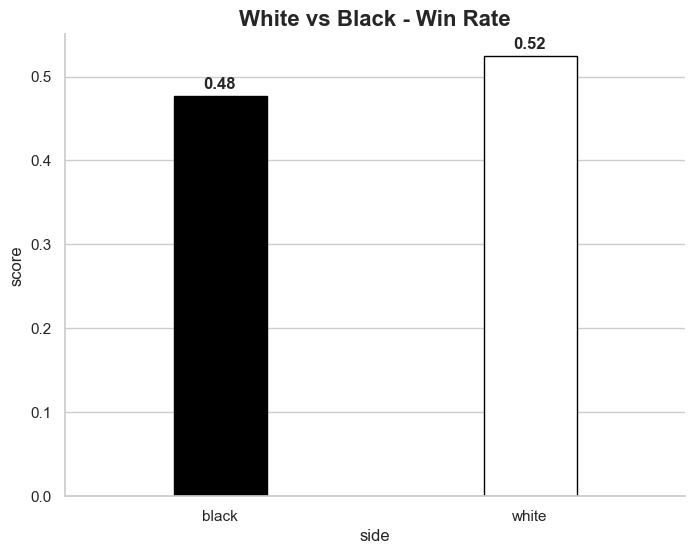

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#000", "#FFF"]
ax.set_title("White vs Black - Win Rate", fontsize=16, weight="bold")
sns.set_style("white")
plot = sns.barplot(white_black, x="side", y="score", palette=colors,hue="side",edgecolor="black",width=0.3)
for container in plot.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, weight='bold')
sns.despine()
plt.show()

### Games count by hour

In [13]:
df["hour"].value_counts().sort_index()

hour
0      787
1      304
2      119
3       51
4       12
5        5
6        9
7      117
8     1044
9      656
10     868
11    1158
12    1349
13     985
14    1387
15    1414
16    1189
17    1037
18    1241
19    1003
20    1522
21    1614
22    1746
23    1390
Name: count, dtype: int64

### Winrate by hour

In [14]:
hourly = (
    df.groupby("hour")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    })
)

hourly

,score,games
hour,,
0,0.522872,787
1,0.481908,304
2,0.462185,119
3,0.450980,51
4,0.500000,12
5,0.600000,5
6,0.111111,9
7,0.517094,117
8,0.477490,1044


### Plot

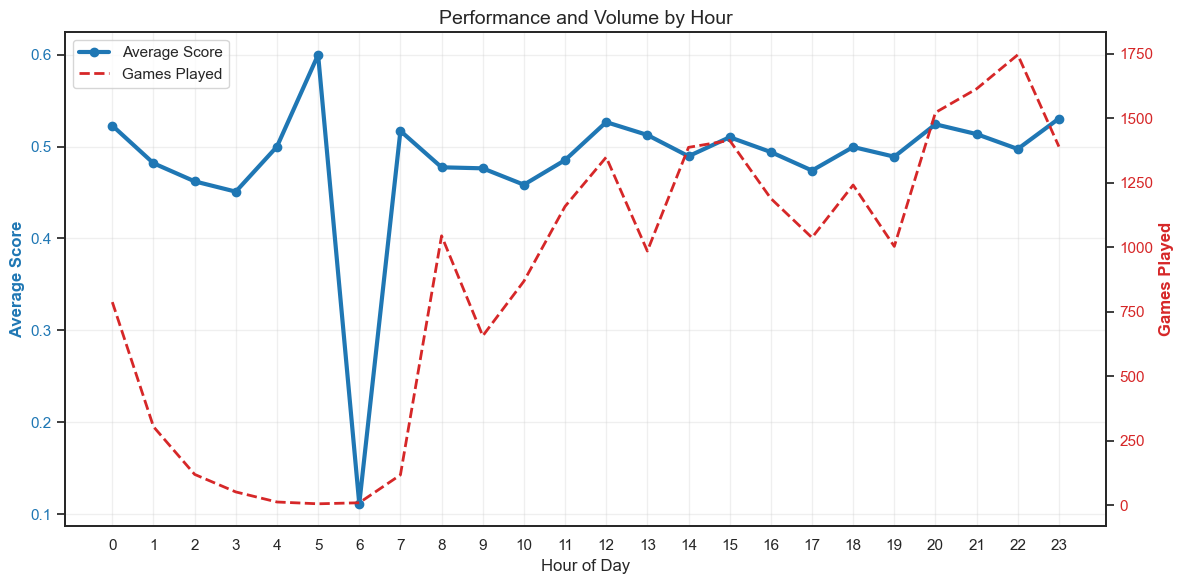

In [15]:
plt.figure(figsize=(12, 6))

# --- PRIMA SERIE: Score (Asse Y Sinistro) ---
ax1 = plt.gca() # Ottieni l'asse corrente
ax1.plot(
    hourly.index,
    hourly["score"],
    color="tab:blue",
    linewidth=3,
    label="Average Score",
    marker='o' # Aggiunge dei punti per ogni ora
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")
ax1.set_xticks(range(24))

# --- SECONDA SERIE: Games (Asse Y Destro) ---
ax2 = ax1.twinx() # Crea un secondo asse che condivide l'asse X
ax2.plot(
    hourly.index,
    hourly["games"],
    color="tab:red",
    linewidth=2,
    linestyle="--", # Linea tratteggiata per distinguerla
    label="Games Played"
)
ax2.set_ylabel("Games Played", color="tab:red", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:red")

# --- TITOLO E GRIGLIA ---
plt.title("Performance and Volume by Hour", fontsize=14)
ax1.grid(True, alpha=0.3) # Griglia leggera basata sull'asse principale

# Opzionale: Unire le legende di entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()


## Weekday performance

In [16]:
weekday_perf = (
    df.groupby("weekday")
    ["score"]
    .mean()
)

weekday_perf

weekday
Friday       0.507251
Monday       0.504902
Saturday     0.494857
Sunday       0.488493
Thursday     0.496376
Tuesday      0.513866
Wednesday    0.497994
Name: score, dtype: float64

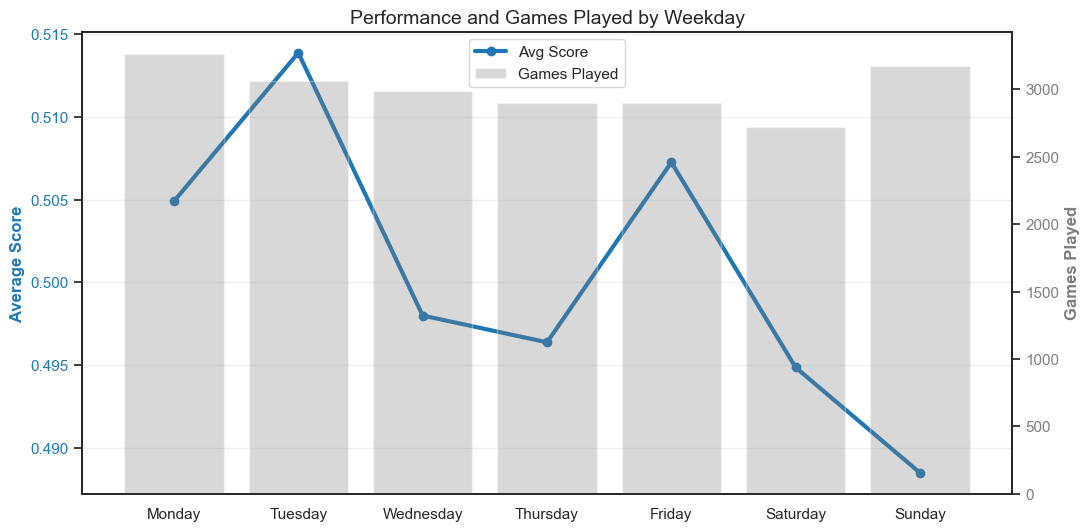

In [17]:
weekday_stats = (
    df.groupby("weekday")
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={"url": "games"})
)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

weekday_stats = weekday_stats.reindex(days_order)

plt.figure(figsize=(12, 6))

ax1 = plt.gca()
ax1.plot(weekday_stats.index, weekday_stats["score"], color="tab:blue", marker='o', linewidth=3, label="Avg Score")
ax1.set_ylabel("Average Score", color="tab:blue", fontweight="bold")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.bar(weekday_stats.index, weekday_stats["games"], color="tab:gray", alpha=0.3, label="Games Played")
ax2.set_ylabel("Games Played", color="tab:gray", fontweight="bold")
ax2.tick_params(axis='y', labelcolor="tab:gray")

plt.title("Performance and Games Played by Weekday", fontsize=14)
ax1.grid(True, axis='y', alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
bars, labels_b = ax2.get_legend_handles_labels()
ax1.legend(lines + bars, labels + labels_b, loc="upper center")

plt.show()


## Opening analysis

### Minimum games filter

We are looking at openings that have been used at least 200 times

In [18]:
opening_stats = (
    df.groupby(["opening","side"])
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "url": "games"
    }) .sort_values(by="score", ascending=False)
)

opening_stats = opening_stats[
    opening_stats["games"] >= 200
]

### Most Used Openings

In [19]:
opening_stats.sort_values(
    "games",
    ascending=False
).reset_index()

,opening,side,score,games
0,Vienna Game,white,0.608583,967
1,Kings Pawn Opening,black,0.572347,933
2,Four Knights Game Scotch Variation Accepted,white,0.528495,930
3,Three Knights Opening,white,0.535834,893
4,Scandinavian Defense Closed,white,0.432555,771
5,Petrovs Defense Three Knights Game,white,0.533835,532
6,Scandinavian Defense,white,0.452830,477
7,Scotch Game,black,0.461957,460
8,Englund Gambit,black,0.463145,407
9,Four Knights Game Scotch Variation,white,0.572559,379


### Best openings

In [20]:
opening_stats.sort_values(
    "score",
    ascending=False
).reset_index().head(10)

,opening,side,score,games
0,Vienna Game,white,0.608583,967
1,Vienna Game Anderssen Defense,white,0.602310,303
2,Four Knights Game Scotch Variation,white,0.572559,379
3,Kings Pawn Opening,black,0.572347,933
4,French Defense Queens Knight Variation,white,0.543175,359
5,Philidor Defense,white,0.538710,310
6,Three Knights Opening,white,0.535834,893
7,Petrovs Defense Three Knights Game,white,0.533835,532
8,Four Knights Game Scotch Variation Accepted,white,0.528495,930
9,Kings Pawn Opening Leonardis Variation,black,0.525316,237


## Rating difference analysis

How do I perform against better rated opponents?

### Bucket ratings

In [21]:
df["rating_bucket"] = pd.cut(
    df["rating_diff"],
    bins=[
        -1000,
        -300,
        -100,
        100,
        300,
        1000
    ]
)

### Performance

In [22]:
rating_perf = (
    df.groupby(["rating_bucket"], observed=False)
    ["score"]
    .mean()
)

rating_perf

rating_bucket
(-1000, -300]    0.111111
(-300, -100]     0.119617
(-100, 100]      0.499172
(100, 300]       0.935685
(300, 1000]      1.000000
Name: score, dtype: float64

### Plot

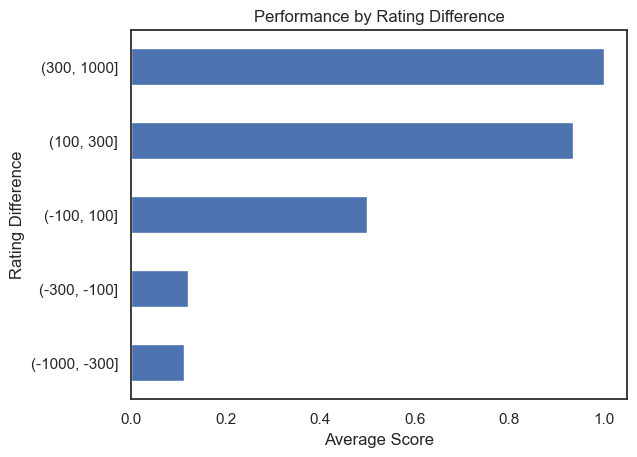

In [23]:
rating_perf.plot(kind="barh")

plt.title(
    "Performance by Rating Difference"
)

plt.xlabel("Average Score")
plt.ylabel("Rating Difference")

plt.show()

## How I win, lose or draw

### Data Prep

In [24]:
wins = df[df['result'] == 'win' ]
draws = df[df['result'] == 'draw' ]
losses = df[df['result'] == 'loss' ]

In [25]:
wins_perc = wins.groupby(['opponent_result'])['result'].count().reset_index(name='count')

wins_perc['percentage'] = round((wins_perc['count'] / wins_perc['count'].sum()) * 100,2)

draws_perc = draws.groupby(['opponent_result'])['result'].count().reset_index(name='count')

draws_perc['percentage'] = round((draws_perc['count'] / draws_perc['count'].sum()) * 100,2)

losses_perc = losses.groupby(['player_result'])['result'].count().reset_index(name='count')

losses_perc['percentage'] = round((losses_perc['count'] / losses_perc['count'].sum()) * 100,2)


### Plot

In [26]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99',"#a099ff"]

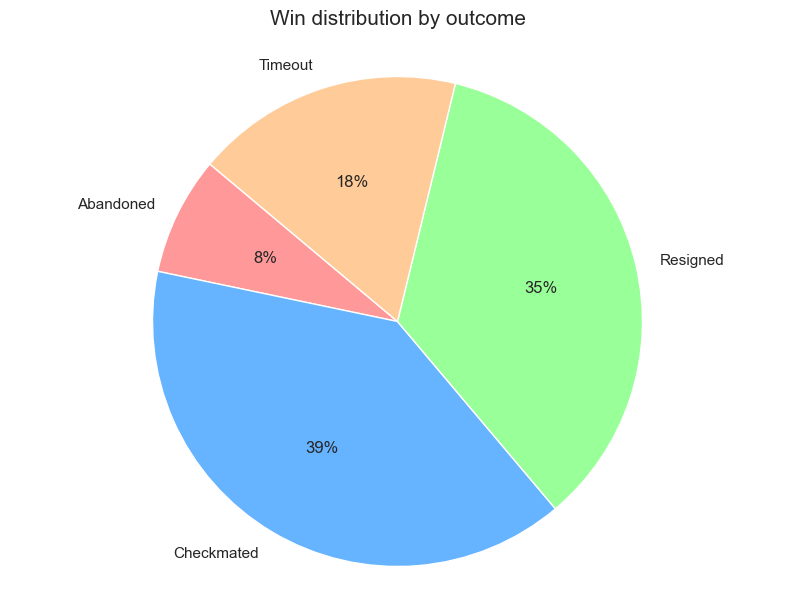

In [27]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    wins_perc['count'], 
    labels=[n.title() for n in wins_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Win distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

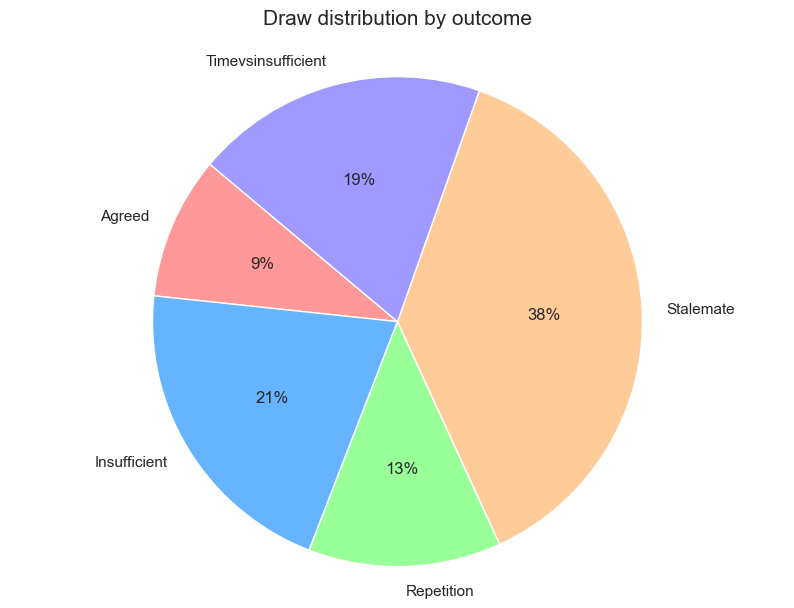

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    draws_perc['count'], 
    labels=[n.title() for n in draws_perc['opponent_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Draw distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

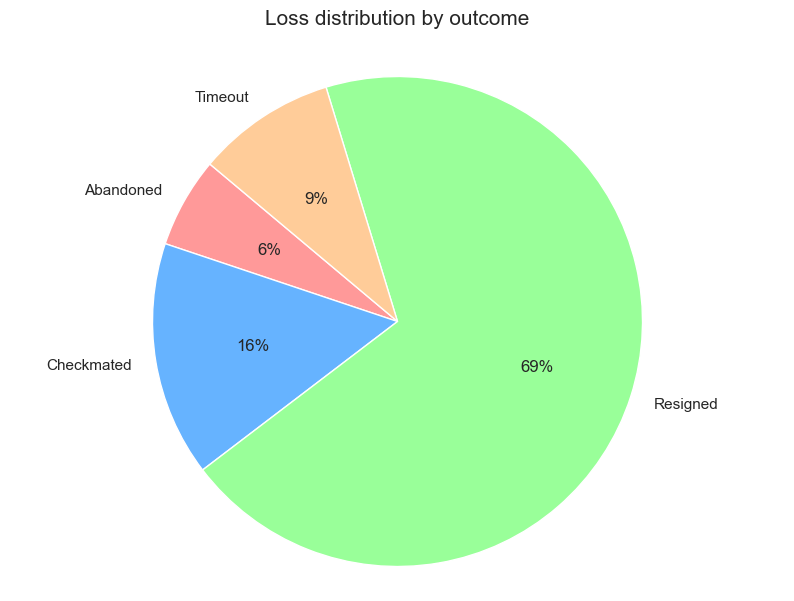

In [29]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.pie(
    losses_perc['count'], 
    labels=[n.title() for n in losses_perc['player_result']] , 
    autopct='%1.0f%%', # Mostra una cifra decimale
    startangle=140, 
    colors=colors, 
)

ax.set_title('Loss distribution by outcome', fontsize=15, pad=20)

plt.axis('equal') 
plt.show()

## Geographical analysis

### Cleaning

In [30]:
geo_games = df.dropna()
geo_games["country_code"].isna().mean()

np.float64(0.0)

### Aggregation

In [31]:
country_counts = (
    geo_games.groupby(["country_name", "iso3"])
    .size()
    .reset_index(name="games")
    .sort_values("games", ascending=False)
)


country_counts.head()

,country_name,iso3,games
197,United States,USA,3046
82,India,IND,1964
61,France,FRA,1042
196,United Kingdom,GBR,831
26,Brazil,BRA,806


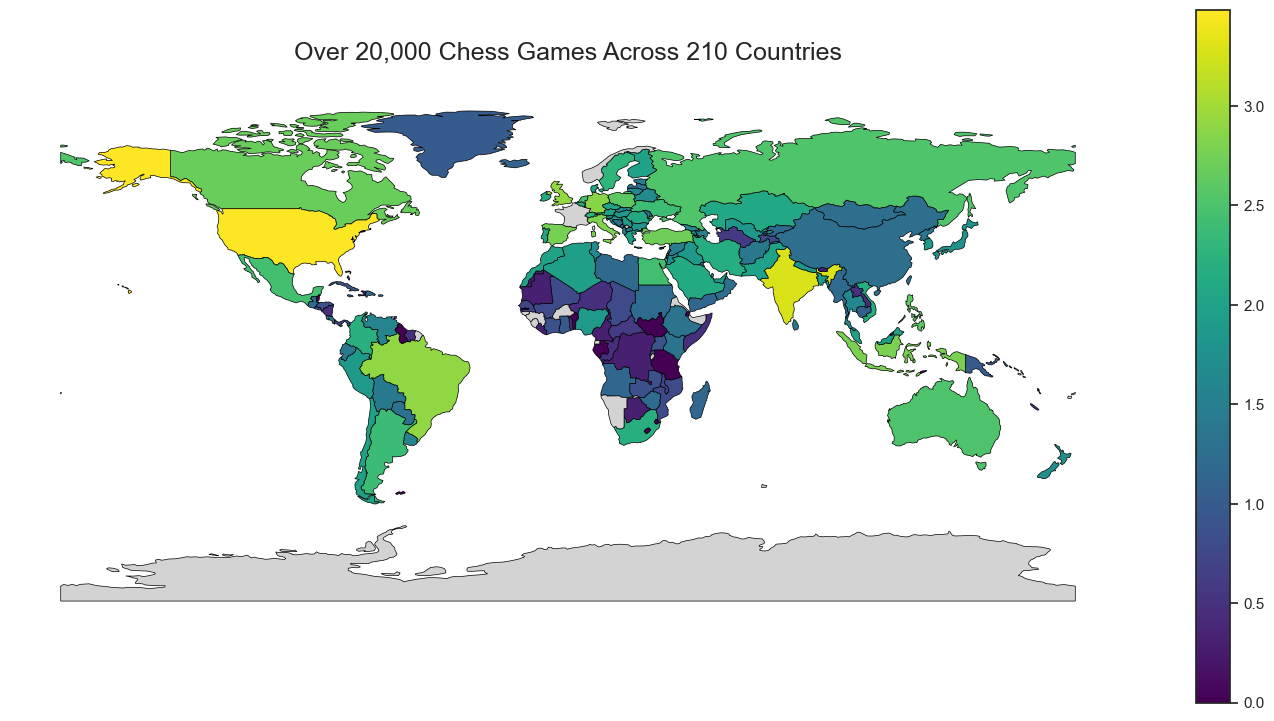

In [32]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

country_counts["Games"] = np.log10(country_counts["games"])

world_counts = world.merge(
    country_counts,
    left_on="ISO_A3",
    right_on="iso3",
    how="left"
)

fig, ax = plt.subplots(figsize=(18, 9))

world_counts.plot(
    column="Games",
    cmap="viridis",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    f"Over 20,000 Chess Games Across {len(country_counts)} Countries",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.show()

### Win rate by country

In [33]:
country_win_rate = (
    geo_games
    .groupby(["country_code", "country_name", "iso3"])
    .agg({
        "score": "mean",
        "url": "count"
    })
    .rename(columns={
        "score": "Win Rate",
        "url": "games"
    })
    .sort_values(by="Win Rate",ascending=False)
    .reset_index()
)

country_win_rate = country_win_rate[
    country_win_rate["games"] >= 20
]

country_win_rate.head()

,country_code,country_name,iso3,Win Rate,games
40,EC,Ecuador,ECU,0.660000,25
42,AL,Albania,ALB,0.650000,30
44,KP,"Korea, Democratic People's Republic of",PRK,0.625000,24
45,BO,"Bolivia, Plurinational State of",BOL,0.615385,26
46,GR,Greece,GRC,0.606061,99


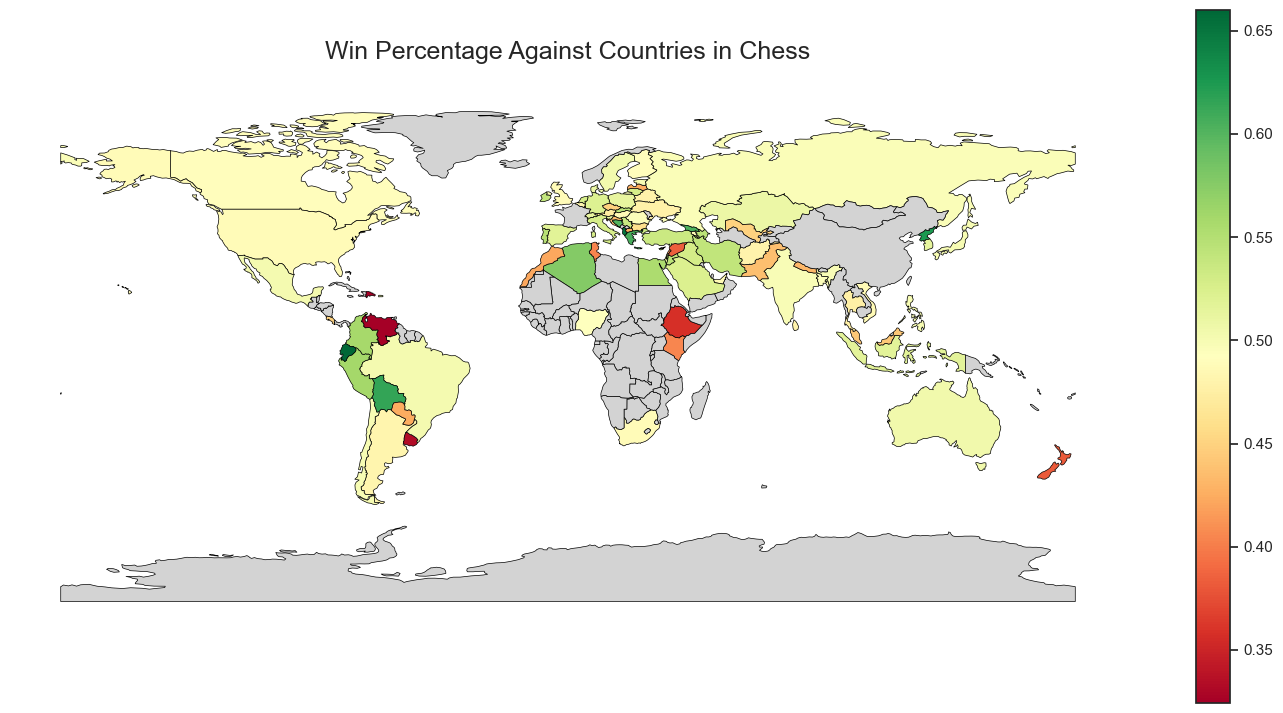

In [34]:


world_winrate = world.merge(
    country_win_rate,
    left_on="ISO_A3",
    right_on="iso3",
    how="left"
)

fig, ax = plt.subplots(figsize=(18, 9))

world_winrate.plot(
    column="Win Rate",
    cmap="RdYlGn",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Win Percentage Against Countries in Chess",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.show()

### Average opponent rating by country

In [35]:
country_avg_rating = (
    geo_games
    .groupby(["country_code", "country_name", "iso3"])
    .agg({
        "opponent_rating": "mean",
        "url": "count"
    })
    .rename(columns={
        "opponent_rating": "Opponent Rating",
        "url": "games"
    })
    .sort_values(by="Opponent Rating",ascending=False)
    .reset_index()
)

country_avg_rating = country_avg_rating[
    country_avg_rating["games"] >= 50
]

country_avg_rating.head(20)

,country_code,country_name,iso3,Opponent Rating,games
37,UZ,Uzbekistan,UZB,675.242857,70
43,MA,Morocco,MAR,666.872549,102
49,MY,Malaysia,MYS,663.505263,95
50,BD,Bangladesh,BGD,663.197531,81
57,NG,Nigeria,NGA,659.770270,74
59,IQ,Iraq,IRQ,659.352113,71
62,IR,"Iran, Islamic Republic of",IRN,657.468966,145
67,NP,Nepal,NPL,652.692308,65
75,PE,Peru,PER,648.026316,76
77,ID,Indonesia,IDN,647.695082,610


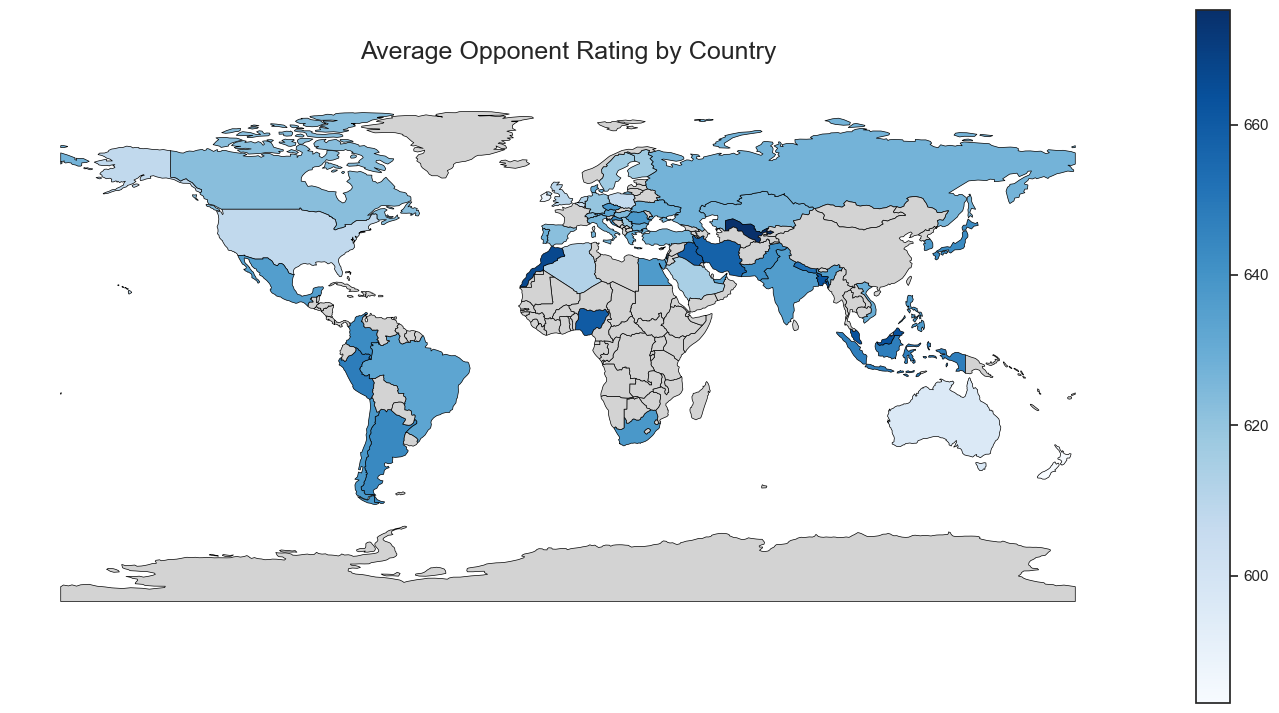

In [36]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

world_rating = world.merge(
    country_avg_rating,
    left_on="ISO_A3",
    right_on="iso3",
    how="left"
)

fig, ax = plt.subplots(figsize=(18, 9))

world_rating.plot(
    column="Opponent Rating",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
    ax=ax
)

ax.set_title(
    "Average Opponent Rating by Country",
    fontsize=18,
    pad=20
)

ax.axis("off")

plt.show()

## Correlation analysis

In [37]:
numeric_cols = [
    "player_rating",
    "opponent_rating",
    "rating_diff",
    "score"
]

df[numeric_cols].corr()

,player_rating,opponent_rating,rating_diff,score
player_rating,1.000000,0.948381,0.043687,0.032586
opponent_rating,0.948381,1.000000,-0.275399,-0.126100
rating_diff,0.043687,-0.275399,1.000000,0.496024
score,0.032586,-0.126100,0.496024,1.000000


# Initial Findings

Some interesting early observations:

- Performance appears to vary significantly by hour of day
- Certain openings consistently outperform others
- White and Black performance differ noticeably
- Rating difference heavily impacts expected results

# Act — Conclusions & Recommendations

## Summary

This analysis examined over 20,000 personal Chess.com games across multiple formats, time periods, and opponent profiles. The goal was to identify which conditions consistently produce better results, so the player can make data-driven decisions about how and when to play.

---

## Key Findings

| Area | Finding |
|---|---|
| **Time of day** | Win rate varies significantly by hour — peak performance windows exist and are identifiable |
| **Day of week** | Certain weekdays show higher average scores; volume and performance do not always peak together |
| **Color** | A measurable gap exists between White and Black performance |
| **Openings** | Among openings played 500+ times, a clear ranking emerges — some consistently outperform the average, others underperform |
| **Rating difference** | Performance degrades predictably against stronger opponents, as expected by Elo theory |
| **Geography** | Win rate and average opponent strength vary meaningfully by country |

---

## Recommendations

### 1. Schedule competitive games during peak hours
The data shows a clear performance window during the day. Scheduling rated games during those hours — and avoiding late-night or early-morning sessions — is the single highest-leverage behavioral change available.

### 2. Use high-performance days for rated games
If performance is consistently better on certain weekdays, those days should be prioritized for competitive play. Lower-performance days can be reserved for casual games or opening experimentation.

### 3. Build the repertoire around proven openings
Openings with 500+ games and an above-average score are statistically validated for this player's style. Deepening preparation in those lines is more efficient than experimenting with new ones.

### 4. Focus competitive effort on the strongest format
If one time class (Bullet, Blitz, or Rapid) shows a stronger and more consistent rating trajectory, competitive energy should be concentrated there rather than spread evenly across all formats.

### 5. Use opponent country data as a calibration tool
Countries with a higher average opponent rating can be treated as useful benchmarks. Tracking performance against those segments over time is a good proxy for overall improvement.

---

## Limitations

- Data reflects only one player's history — findings are not generalizable without further research
- The Chess.com rating system is format-specific and not directly comparable across Bullet, Blitz, and Rapid
- Country-level analysis excludes opponents with no country data in their profile (~small % of games)
- Opening analysis requires a minimum of 500 games per opening, which filters out rare or experimental lines

---

## Further Exploration

- **Move-level analysis** using PGN data to identify whether games are won/lost in the opening, middlegame, or endgame
- **Time-series forecasting** to project rating trajectories under different training regimens
- **Opponent recurrence analysis** — does performance change against repeat opponents?
- **Opening repertoire dashboard** combining win rate, frequency, and opponent response distribution
- **Tilt detection** — does performance degrade after a losing streak in the same session?


## Export Tables

In [38]:
EXPORT_DIR = (
    PROJECT_ROOT
    / "dataset"
    / "processed"
    / USERNAME
)

opening_stats.to_csv(
    EXPORT_DIR / "opening_stats.csv"
)

hourly.to_csv(
    EXPORT_DIR / "hourly_performance.csv"
)

test moves

In [39]:
def extract_move_data(pgn_text, time_control, game_id):

    try:

        time_control = int(time_control)

        pgn_io = io.StringIO(pgn_text)

        game = chess.pgn.read_game(pgn_io)

        if game is None:
            return []

        board = game.board()

        rows = []

        previous_white_clock = time_control
        previous_black_clock = time_control

        for node in game.mainline():

            move = node.move

            if move is None:
                continue

            san = board.san(move)

            move_number = board.fullmove_number

            color = "white" if board.turn else "black"

            remaining_time = node.clock()

            if remaining_time is None:
                board.push(move)
                continue

            # Calculate move time
            if color == "white":

                move_time = (
                    previous_white_clock -
                    remaining_time
                )

                previous_white_clock = remaining_time

            else:

                move_time = (
                    previous_black_clock -
                    remaining_time
                )

                previous_black_clock = remaining_time

            # Avoid impossible values
            if move_time < 0:
                move_time = np.nan

            rows.append({

                "game_id": game_id,
                "move_number": move_number,
                "color": color,
                "san": san,
                "move_time": move_time,
                "remaining_time": remaining_time

            })

            board.push(move)

        return rows

    except Exception:

        return []

In [40]:
PROJECT_ROOT = Path().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import USERNAME

DATA_PATH = (
    PROJECT_ROOT
    / "dataset"
    / "raw"
    / USERNAME
    / "games.csv"
)

pgn_df = pd.read_csv(DATA_PATH)

pgn_df["date"] = pd.to_datetime(df["date"])

pgn_df.head()

,date,url,time_class,time_control,white,black,white_rating,black_rating,white_result,black_result,eco,pgn,opponent,opponent_clean
0,2020-11-10 15:30:24,https://www.chess.com/game/live/5719328865,rapid,600,elmurie,TheMrNoName,213,412,resigned,win,https://www.chess.com/openings/Polish-Opening-...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",TheMrNoName,themrnoname
1,2020-11-10 15:46:19,https://www.chess.com/game/live/5719418873,rapid,600,smackersmashbot,elmurie,216,345,resigned,win,https://www.chess.com/openings/Kings-Pawn-Open...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",smackersmashbot,smackersmashbot
2,2020-11-10 16:09:31,https://www.chess.com/game/live/5719482469,rapid,600,amkh98,elmurie,371,256,win,checkmated,https://www.chess.com/openings/Kings-Pawn-Open...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",amkh98,amkh98
3,2020-11-10 17:39:54,https://www.chess.com/game/live/5720005454,rapid,600,elmurie,callumfindlay4,193,330,checkmated,win,https://www.chess.com/openings/Vienna-Game-Max...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",callumfindlay4,callumfindlay4
4,2020-11-10 17:51:42,https://www.chess.com/game/live/5720050101,rapid,600,callumfindlay4,elmurie,291,277,resigned,win,https://www.chess.com/openings/Caro-Kann-Defen...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",callumfindlay4,callumfindlay4


In [41]:
pgn_df["time_control"] = pgn_df["time_control"].astype(str).str.strip()
blitz_df = pgn_df.query("time_class == 'blitz' and time_control == '180'").copy()
blitz_df = blitz_df.reset_index(drop=True)

blitz_df["game_id"] = blitz_df.index.astype("int32")
sample_df = blitz_df.sample(
    650,
    random_state=42
)

In [42]:
# move_times_df = extract_move_times(test_game["pgn"],test_game["time_control"] )

In [43]:
sample_df.head()

,date,url,time_class,time_control,white,black,white_rating,black_rating,white_result,black_result,eco,pgn,opponent,opponent_clean,game_id
4715,2024-08-13 16:55:26,https://www.chess.com/game/live/108698713462,blitz,180,joonscarebear,elmurie,659,665,checkmated,win,https://www.chess.com/openings/Nimzowitsch-Lar...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",joonscarebear,joonscarebear,4715
1697,2024-01-15 21:04:36,https://www.chess.com/game/live/95954664314,blitz,180,elmurie,Quentin33270,582,586,win,timeout,https://www.chess.com/openings/Scandinavian-De...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",Quentin33270,quentin33270,1697
8875,2025-03-14 15:45:48,https://www.chess.com/game/live/136257033574,blitz,180,QGambit007,elmurie,677,661,win,resigned,https://www.chess.com/openings/Nimzowitsch-Lar...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",QGambit007,qgambit007,8875
4840,2024-08-18 12:43:48,https://www.chess.com/game/live/108780378606,blitz,180,nikunjbrahm29,elmurie,650,684,resigned,win,https://www.chess.com/openings/Kings-Pawn-Open...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",nikunjbrahm29,nikunjbrahm29,4840
6482,2024-12-06 01:15:24,https://www.chess.com/game/live/121295148198,blitz,180,sumowumo1,elmurie,612,609,abandoned,win,https://www.chess.com/openings/Queens-Pawn-Ope...,"[Event ""Live Chess""]\n[Site ""Chess.com""]\n[Dat...",sumowumo1,sumowumo1,6482


In [44]:
all_moves = []

for _, row in sample_df.iterrows():

    moves = extract_move_data(

        pgn_text=row["pgn"],
        time_control=row["time_control"],
        game_id=row["game_id"]

    )

    all_moves.extend(moves)

In [45]:
moves_df = pd.DataFrame(all_moves)

Cleaning

In [46]:
moves_df = moves_df[
    moves_df["move_time"].notna()
]

moves_df = moves_df[
    moves_df["move_time"] >= 0
]

moves_df = moves_df[
    moves_df["move_time"] <= 180
]

Game Result

In [47]:
moves_df = moves_df.merge(

    sample_df[
        [
            "game_id",
            "white_result",
            "black_result",
            "white_rating",
            "black_rating",
            "eco"
        ]
    ],

    on="game_id",
    how="left"
)

Add Phase

In [48]:
def assign_phase(move_number):

    if move_number <= 8:
        return "opening"

    elif move_number <= 20:
        return "early_middlegame"

    elif move_number <= 35:
        return "late_middlegame"

    return "endgame"

moves_df["phase"] = moves_df[
    "move_number"
].apply(assign_phase)

Add Pressure Flags

In [49]:
moves_df["under_60"] = (
    moves_df["remaining_time"] < 60
)

moves_df["under_30"] = (
    moves_df["remaining_time"] < 30
)

moves_df["under_10"] = (
    moves_df["remaining_time"] < 10
)

moves_df["under_5"] = (
    moves_df["remaining_time"] < 5
)

1. Distribution of Move Times

In [50]:
moves_df["move_time"].describe()

count    39256.000000
mean         3.140957
std          3.532689
min          0.000000
25%          1.100000
50%          2.000000
75%          3.900000
max         85.600000
Name: move_time, dtype: float64

2. Longest Thinks

In [51]:
moves_df.sort_values(
    "move_time",
    ascending=False
).head(20)

,game_id,move_number,color,san,move_time,remaining_time,white_result,black_result,white_rating,black_rating,eco,phase,under_60,under_30,under_10,under_5
38176,13707,18,black,Nxh1,85.6,12.7,win,resigned,717,721,https://www.chess.com/openings/Van-Geet-Openin...,early_middlegame,True,True,False,False
6477,9930,5,white,exd5,78.1,92.3,resigned,win,793,819,https://www.chess.com/openings/Italian-Game-Kn...,opening,False,False,False,False
11976,291,13,black,f5,67.4,78.3,win,timeout,528,574,https://www.chess.com/openings/Scandinavian-De...,early_middlegame,False,False,False,False
26437,13653,17,black,Bxe6,57.2,85.7,win,resigned,672,671,https://www.chess.com/openings/Scandinavian-De...,early_middlegame,False,False,False,False
605,9213,27,black,Ra4,51.3,44.7,win,checkmated,682,654,https://www.chess.com/openings/Scandinavian-De...,late_middlegame,True,False,False,False
25454,12644,17,black,d4,48.3,75.7,win,timeout,779,760,https://www.chess.com/openings/Four-Knights-Ga...,early_middlegame,False,False,False,False
35572,14315,29,black,Qxb3,46.8,84.0,timevsinsufficient,timevsinsufficient,742,738,https://www.chess.com/openings/Italian-Game-Tw...,late_middlegame,False,False,False,False
25441,12644,11,white,Bxe6,46.4,124.9,win,timeout,779,760,https://www.chess.com/openings/Four-Knights-Ga...,early_middlegame,False,False,False,False
7024,11860,14,black,Rad8,45.5,111.3,win,resigned,769,746,https://www.chess.com/openings/Queens-Gambit-D...,early_middlegame,False,False,False,False
12032,13538,5,white,Be2,44.5,92.5,resigned,win,546,563,https://www.chess.com/openings/Reti-Opening-1....,opening,False,False,False,False


3. Average Move Time by Phase

In [52]:
moves_df.groupby(
    "phase"
)["move_time"].mean()

phase
early_middlegame    4.047536
endgame             2.038752
late_middlegame     3.705052
opening             2.029432
Name: move_time, dtype: float64

4. Remaining Clock by Move Number

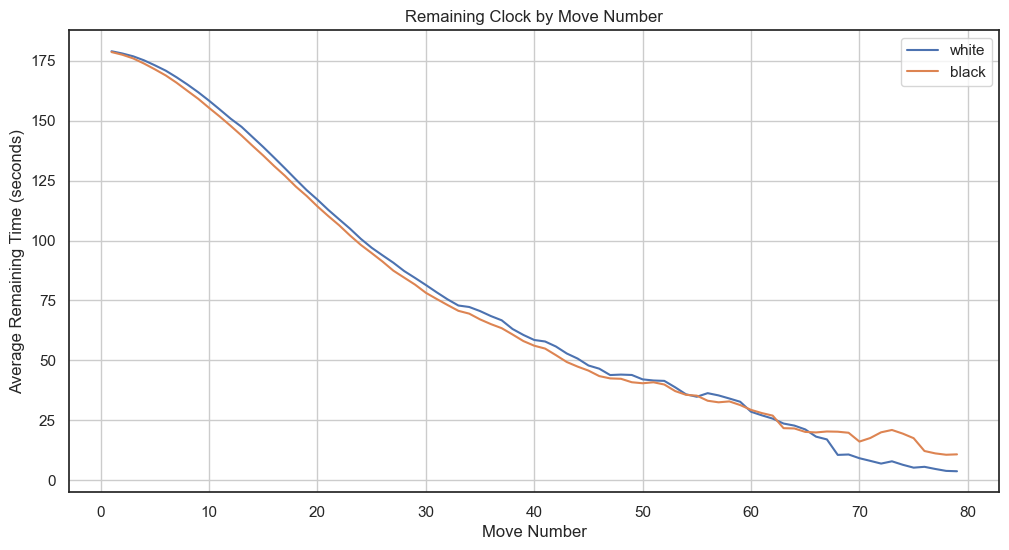

In [53]:
clock_curve_color = (
    moves_df
    .groupby(
        ["move_number", "color"]
    )
    ["remaining_time"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for color in ["white", "black"]:

    subset = clock_curve_color[
        clock_curve_color["color"] == color
    ]

    plt.plot(
        subset["move_number"],
        subset["remaining_time"],
        label=color
    )

plt.xlabel("Move Number")
plt.ylabel("Average Remaining Time (seconds)")

plt.title("Remaining Clock by Move Number")

plt.legend()

plt.grid(True)

plt.show()

5. Time Pressure Frequency

In [54]:
moves_df["under_10"].mean()

np.float64(0.017627878540859995)

Create Player Perspective Result

In [55]:
moves_df["player_result"] = np.where(

    (
        (moves_df["color"] == "white")
        &
        (moves_df["white_result"] == "win")
    )

    |

    (
        (moves_df["color"] == "black")
        &
        (moves_df["black_result"] == "win")
    ),

    "win",

    "loss"
)

Clock Curve by Result

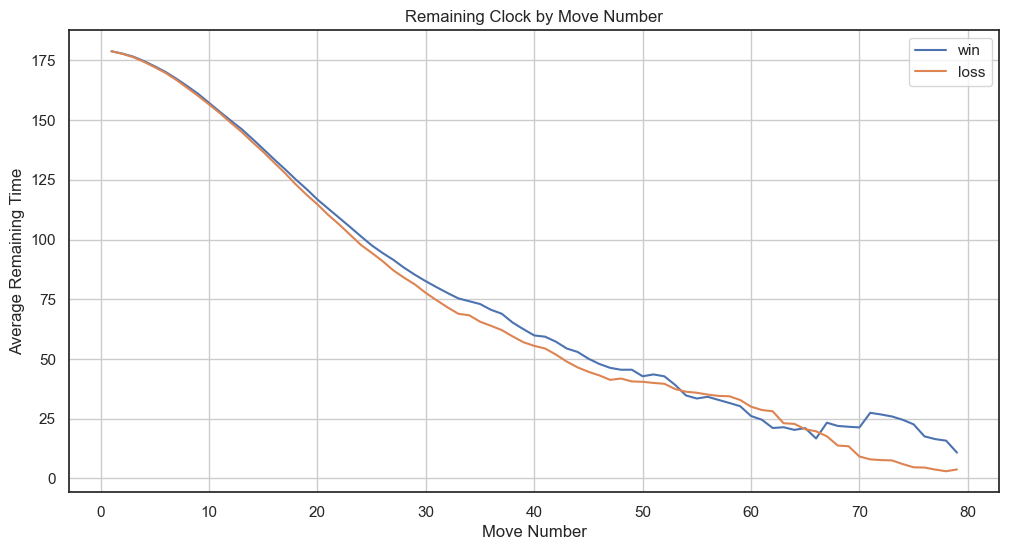

In [56]:
clock_curve_result = (
    moves_df
    .groupby(
        ["move_number", "player_result"]
    )
    ["remaining_time"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

for result in ["win", "loss"]:

    subset = clock_curve_result[
        clock_curve_result["player_result"] == result
    ]

    plt.plot(
        subset["move_number"],
        subset["remaining_time"],
        label=result
    )

plt.xlabel("Move Number")
plt.ylabel("Average Remaining Time")

plt.title(
    "Remaining Clock by Move Number"
)

plt.legend()

plt.grid(True)

plt.show()

THIS Is The Interesting Part

If winners consistently retain more time:

that’s already a meaningful insight.

Possible interpretation:

Better time management correlates strongly with winning in 3-minute blitz.

# Average Clock Loss Per Move

In [76]:
clock_spent_curve = (
    moves_df
    .groupby(["move_number","player_result"])
    ["move_time"]
    .mean()
    .reset_index()
)


median_game_length  = (
    moves_df
    .groupby("game_id")["move_number"]
    .max()
    .median()
)

clock_spent_curve

,move_number,player_result,move_time
0,1,loss,1.169941
1,1,win,1.181877
2,2,loss,1.085044
3,2,win,0.969417
4,3,loss,1.425660
...,...,...,...
153,77,win,1.150000
154,78,loss,0.700000
155,78,win,0.650000
156,79,loss,1.400000


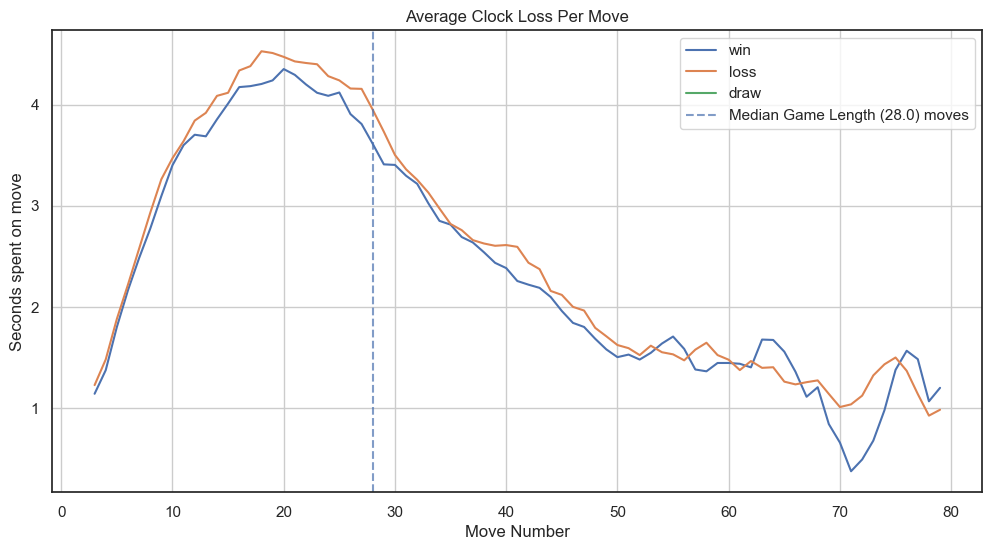

In [75]:
plt.figure(figsize=(12,6))

for result in ["win", "loss", "draw"]:

    subset = clock_spent_curve[
        clock_spent_curve["player_result"] == result
    ]

    plt.plot(
        subset["move_number"],
        subset["move_time"].rolling(3).mean(),
        label=result
    )

plt.xlabel("Move Number")
plt.ylabel("Seconds spent on move")

plt.title(
    "Average Clock Loss Per Move"
)

plt.axvline(
    median_game_length ,
    linestyle="--",
    alpha=0.7,
    label=f"Median Game Length ({median_game_length :.1f}) moves"
)

plt.legend()

plt.grid(True)

plt.show()
